# 04 - Model 4: Transformer encoder trained from scratch
Self-attention connects every pair of tokens directly (Vaswani et al., 2017), a different mechanism from the LSTM's step-by-step recurrence. Trained from scratch on 6.7k tweets, it tests how much a Transformer can learn from this dataset alone, and gives a no-pretraining reference point for the fine-tuned BERTweet (Model 5).

The encoder is pre-LayerNorm (Xiong et al., 2020), uses a padding mask, and classifies from a learned `[CLS]` vector or the mean of the token states. Without positional encodings self-attention is permutation-invariant, so experiment **T1** directly measures how much word order the model uses.

| Exp | Question | Varied | Fixed |
|---|---|---|---|
| T1 | **Does word order matter?** | positional encoding: none / sinusoidal / learned | 2 layers, d=128, word vocab, CLS |
| T2 | How big a model can 6.7k tweets support? | layers {1, 2} x d_model {64, 128} | best T1 |
| T3 | Word vs subword tokens (rare-word problem) | word vocab vs BPE (5k merges) | best T2 |
| T4 | Does GloVe initialisation help a Transformer? | random vs GloVe-100 (d_model=100, word vocab) | best T3 |
| T5 | Pooling and learning-rate warm-up | CLS vs mean pooling x warm-up 0 / 10% | best T4 |

All runs: 4 heads, feed-forward size 2 x d_model, dropout 0.2, AdamW (lr 5e-4, weight decay 0.01), class-weighted cross-entropy, early stopping on validation macro-F1 (patience 5, max 30 epochs). Every config is trained with **3 seeds** and compared on the mean (see notebook 03 for why).

**Runtime:** about 2 h on a laptop CPU, about 15 min on a Colab T4 GPU. Run notebook 03 first: it caches the GloVe vectors this notebook uses in T4.

In [1]:
import os, sys

# Colab: mount Drive and use the project folder there. Local: use the repo root.
if "google.colab" in sys.modules:
    %pip install -q emoji tokenizers
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/formative2-vaccine-sentiment"
    GLOVE_DIR = "/content/glove"               # the 1.5 GB zip goes on Colab's local disk, not Drive
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
    GLOVE_DIR = os.path.join(BASE, "data/embeddings/raw")

for d in ["data/processed", "data/embeddings", "reports/figures", "reports/predictions"]:
    os.makedirs(os.path.join(BASE, d), exist_ok=True)
os.chdir(BASE)
sys.path.insert(0, BASE)
print("Working directory:", os.getcwd())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 22.5 MB/s eta 0:00:00
Mounted at /content/drive
Working directory: /content/drive/MyDrive/formative2-vaccine-sentiment


## Data: word and subword vocabularies
Both vocabularies are built on the training split only. The word vocabulary is the same as notebook 03's. The BPE vocabulary (Sennrich et al., 2016) splits rare words into frequent pieces, so almost nothing is out-of-vocabulary.

In [2]:
import itertools
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from src.preprocessing import load_splits
from src.evaluation import evaluate, save_predictions, plot_history
from src.nn_utils import (DEVICE, UNK, Vocab, BPEVocab, tokenize, make_datasets, make_loaders, class_weights,
                          load_glove_subset, embedding_matrix, fit, predict, slice_report)
from src.models import TransformerClassifier
from src.experiments import Experiments, plot_sweep, history_table

sns.set_theme(style="whitegrid")
FIG, AUTHOR, MODEL = "reports/figures/", "P2", "transformer_scratch"
print("Device:", DEVICE, "| torch threads:", torch.get_num_threads())

train, val, test = load_splits()
CW = class_weights(train)

vocab = Vocab(train["clean_text"], min_freq=2)
bpe = BPEVocab(train["clean_text"], vocab_size=5000)
bpe_lens = pd.Series([len(bpe.encode(t, max_len=10_000)) for t in train["clean_text"]])
val_unk = np.mean([i == UNK for t in val["clean_text"] for i in vocab.encode(t)])
print(f"Word vocab {len(vocab)} (val tokens that are <unk>: {val_unk:.1%}) | BPE vocab {len(bpe)}")
print(f"BPE tokens/tweet: 99th pct {bpe_lens.quantile(.99):.0f}, max {bpe_lens.max()} -> BPE max_len 64")
example = train["clean_text"].iloc[3]
print("Example:", example, "\n  BPE:", bpe.tok.encode(example).tokens)

TOK = {"word": (vocab, make_datasets(train, val, test, vocab, max_len=40)),
       "bpe":  (bpe,   make_datasets(train, val, test, bpe, max_len=64))}

# GloVe-100 for T4 (reads the subset cached by notebook 03; downloads only if it is missing)
EMB100 = embedding_matrix(vocab, load_glove_subset(100, train["clean_text"], glove_dir=GLOVE_DIR), 100)

Device: cuda | torch threads: 1
Word vocab 5100 (val tokens that are <unk>: 9.1%) | BPE vocab 5000
BPE tokens/tweet: 99th pct 35, max 73 -> BPE max_len 64
Example: hard to convince a mother of a 13yo with autism to give any vaccines i worked hard today to get her to maybe had to use my woo! 
  BPE: ['hard', 'to', 'convince', 'a', 'mother', 'of', 'a', '13', 'yo', 'with', 'autism', 'to', 'give', 'any', 'vaccines', 'i', 'worked', 'hard', 'today', 'to', 'get', 'her', 'to', 'maybe', 'had', 'to', 'use', 'my', 'woo', '!']


## Experiment runner
Same `Experiments` runner as notebook 03: 3 seeds per config, every run logged, shared configs trained once.

In [3]:
def train_transformer(cfg, seed, verbose=False):
    voc, ds = TOK[cfg["tok"]]
    if cfg["emb"] == "glove":
        assert cfg["tok"] == "word" and cfg["d_model"] == 100, "GloVe init needs the word vocab and d_model=100"
    train_dl, val_dl, _ = make_loaders(ds, seed=seed)
    model = TransformerClassifier(len(voc), cfg["d_model"], cfg["n_heads"], cfg["n_layers"],
                                  ff_dim=2 * cfg["d_model"], dropout=cfg["dropout"], pos=cfg["pos"],
                                  pooling=cfg["pooling"], embeddings=EMB100 if cfg["emb"] == "glove" else None)
    hist, best = fit(model, train_dl, val_dl, val["label"], epochs=30, patience=5, lr=cfg["lr"],
                     weight_decay=0.01, warmup=cfg["warmup"], class_weights=CW, verbose=verbose)
    return model, hist, best


ex = Experiments(train_transformer, MODEL, author=AUTHOR, seeds=(42, 1, 2),
                 defaults=dict(tok="word", emb="random", d_model=128, n_layers=2, n_heads=4, dropout=0.2,
                               pos="sinusoidal", pooling="cls", lr=5e-4, warmup=0.1))

## T1: positional encoding (does word order matter?)

,pos,val_macro_f1,f1_std,val_rmse,rmse_std,best_epoch,n_params
0,none,0.6084,0.0103,0.6609,0.0265,15.6667,918531
1,sinusoidal,0.5968,0.0194,0.6654,0.0177,13.0000,918531
2,learned,0.5918,0.0069,0.6728,0.0178,18.3333,951299


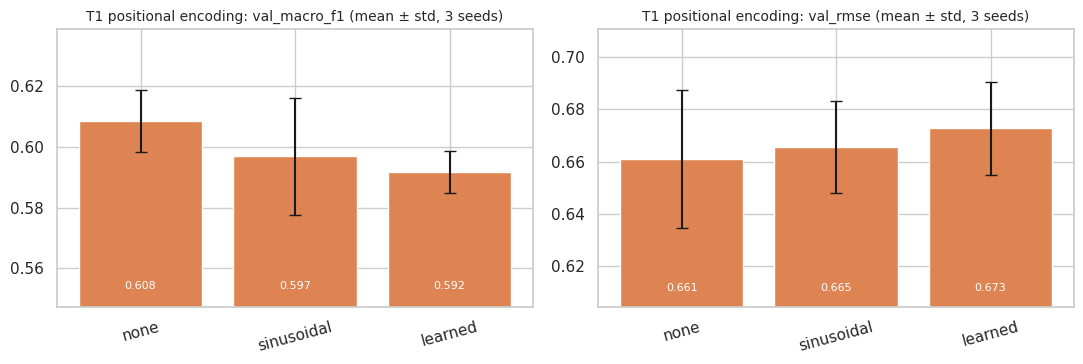

Winner leads the runner-up by 0.0116; seed std 0.0194 -> within seed noise
BEST (mean val macro-F1 0.6084): {'tok': 'word', 'emb': 'random', 'd_model': 128, 'n_layers': 2, 'n_heads': 4, 'dropout': 0.2, 'pos': 'none', 'pooling': 'cls', 'lr': 0.0005, 'warmup': 0.1}


In [4]:
t1 = ex.sweep("T1", [dict(pos="none"), dict(pos="sinusoidal"), dict(pos="learned")])
plot_sweep(t1, "pos", "T1 positional encoding", FIG + "t1_transformer_positions.png", color="#dd8452")
ex.update(t1, ["pos"])

*Interpretation (T1):* positional information gives no measurable benefit. The encoder with no positional encoding, which sees the tweet as an unordered bag of words, scores 0.608, against 0.597 with sinusoidal and 0.592 with learned positions. The 0.012 gap is inside the seed std (0.019), so we cannot say that positions hurt, only that they do not help. This is the most direct evidence in the project on word order: trained from scratch on 6.7k tweets, self-attention does not learn to use it. It does not mean that word order carries no signal, because word bigrams helped both baselines (about +0.025 macro-F1 for TF-IDF and for fastText); it means that this model cannot extract that signal from so little data. `pos="none"` is carried forward because it has the highest mean, so the final Model 4 is order-invariant.

## T2: model size

,n_layers,d_model,val_macro_f1,f1_std,val_rmse,rmse_std,best_epoch,n_params
0,1,64,0.5897,0.0144,0.6607,0.0054,19.6667,360259
1,1,128,0.6039,0.0101,0.6436,0.0066,15.3333,786051
2,2,64,0.5975,0.0080,0.6542,0.0067,13.6667,393731
3,2,128,0.6084,0.0103,0.6609,0.0265,15.6667,918531


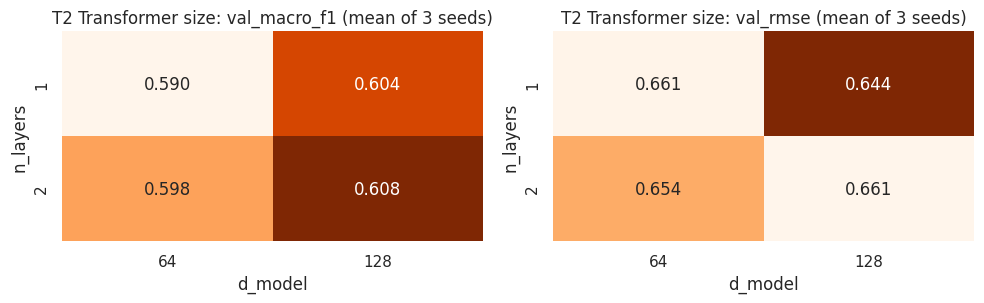

Winner leads the runner-up by 0.0045; seed std 0.0103 -> within seed noise
BEST (mean val macro-F1 0.6084): {'tok': 'word', 'emb': 'random', 'd_model': 128, 'n_layers': 2, 'n_heads': 4, 'dropout': 0.2, 'pos': 'none', 'pooling': 'cls', 'lr': 0.0005, 'warmup': 0.1}


In [5]:
t2 = ex.sweep("T2", [dict(n_layers=l, d_model=d) for l, d in itertools.product([1, 2], [64, 128])])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, m in zip(axes, ["val_macro_f1", "val_rmse"]):
    sns.heatmap(t2.pivot(index="n_layers", columns="d_model", values=m), annot=True, fmt=".3f",
                cmap="Oranges" if m == "val_macro_f1" else "Oranges_r", cbar=False, ax=ax)
    ax.set_title(f"T2 Transformer size: {m} (mean of 3 seeds)")
plt.tight_layout(); plt.savefig(FIG + "t2_transformer_size.png", dpi=200); plt.show()
ex.update(t2, ["n_layers", "d_model"])

*Interpretation (T2):* model size makes little difference. The four configs lie between 0.590 and 0.608, and the winner (2 layers, d_model 128) leads by 0.005, inside the seed std (0.010). The wider embedding helps slightly at both depths (+0.011 to +0.014), and a second layer adds less (+0.005 to +0.008). A model with 360k parameters is within 0.02 of one with 920k, so the Transformer is limited by the data, not by its capacity. The default size is kept.

## T3: word vs BPE subword tokens

In [6]:
t3 = ex.sweep("T3", [dict(tok="word"), dict(tok="bpe")])
ex.update(t3, ["tok"])

,tok,val_macro_f1,f1_std,val_rmse,rmse_std,best_epoch,n_params
0,word,0.6084,0.0103,0.6609,0.0265,15.6667,918531
1,bpe,0.6046,0.0149,0.6568,0.0358,15.3333,905731


Winner leads the runner-up by 0.0037; seed std 0.0149 -> within seed noise
BEST (mean val macro-F1 0.6084): {'tok': 'word', 'emb': 'random', 'd_model': 128, 'n_layers': 2, 'n_heads': 4, 'dropout': 0.2, 'pos': 'none', 'pooling': 'cls', 'lr': 0.0005, 'warmup': 0.1}


*Interpretation (T3):* subword tokens do not help: the word vocabulary scores 0.608 and BPE 0.605 (gap 0.004, seed std 0.015). BPE removes the out-of-vocabulary problem (9.1% of validation tokens are `<unk>` with the word vocabulary), but the pieces of a rare word still have to be learned from the same 6.7k tweets, and the sequences become longer (99th percentile 35 BPE tokens against 28 words). The word vocabulary is kept, which also allows the GloVe initialisation tested in T4.

## T4: GloVe initialisation
Both arms use the word vocabulary and d_model = 100 (the GloVe size), so the only difference is the initial embedding.

In [7]:
t4 = ex.sweep("T4", [dict(tok="word", d_model=100, emb="random"),
                     dict(tok="word", d_model=100, emb="glove")])
ex.update(t4, ["tok", "d_model", "emb"])

,tok,d_model,emb,val_macro_f1,f1_std,val_rmse,rmse_std,best_epoch,n_params
0,word,100,random,0.5952,0.0156,0.6620,0.0133,13.3333,672803
1,word,100,glove,0.6250,0.0035,0.6618,0.0338,14.0000,672803


Winner leads the runner-up by 0.0298; seed std 0.0156 -> clear difference
BEST (mean val macro-F1 0.6250): {'tok': 'word', 'emb': 'glove', 'd_model': 100, 'n_layers': 2, 'n_heads': 4, 'dropout': 0.2, 'pos': 'none', 'pooling': 'cls', 'lr': 0.0005, 'warmup': 0.1}


*Interpretation (T4):* GloVe initialisation is the only change that clearly helps the Transformer: 0.625, against 0.595 with random embeddings of the same size (gap 0.030, about twice the seed std of 0.016). The seed std also falls from 0.016 to 0.004. RMSE does not improve (0.662 in both arms). d_model drops to 100 to match the GloVe size, and random embeddings at 100 (0.595) are slightly below random embeddings at 128 (0.608), so the gain comes from the vectors, not from the size. This matches L1 for the BiLSTM: on this dataset, knowledge from 2B unlabelled tweets is worth more than any architecture choice we tested. It is also the argument for Model 5, which pretrains the whole network and not only the embeddings.

## T5: pooling and warm-up

,pooling,warmup,val_macro_f1,f1_std,val_rmse,rmse_std,best_epoch,n_params
0,cls,0.0,0.6238,0.0023,0.6469,0.0194,8.3333,672803
1,cls,0.1,0.6250,0.0035,0.6618,0.0338,14.0000,672803
2,mean,0.0,0.6242,0.0082,0.6539,0.0254,14.3333,672803
3,mean,0.1,0.6248,0.0092,0.6722,0.0123,13.0000,672803


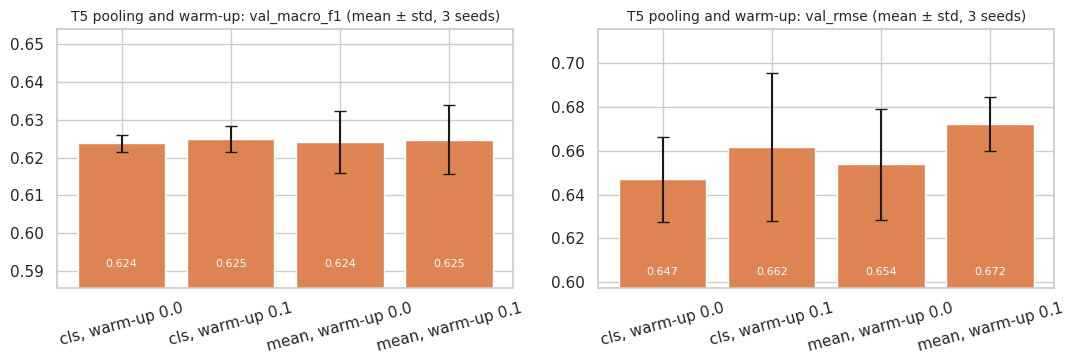

Winner leads the runner-up by 0.0002; seed std 0.0092 -> within seed noise
BEST (mean val macro-F1 0.6250): {'tok': 'word', 'emb': 'glove', 'd_model': 100, 'n_layers': 2, 'n_heads': 4, 'dropout': 0.2, 'pos': 'none', 'pooling': 'cls', 'lr': 0.0005, 'warmup': 0.1}


In [8]:
t5 = ex.sweep("T5", [dict(pooling=p, warmup=w) for p, w in itertools.product(["cls", "mean"], [0.0, 0.1])])
t5["setting"] = t5["pooling"] + ", warm-up " + t5["warmup"].astype(str)
plot_sweep(t5, "setting", "T5 pooling and warm-up", FIG + "t5_transformer_pooling_warmup.png", color="#dd8452")
ex.update(t5, ["pooling", "warmup"])

*Interpretation (T5):* neither pooling nor warm-up matters. The four configs lie between 0.6238 and 0.6250, a spread of 0.001 against a seed std of up to 0.009. Without warm-up the CLS model reaches its best epoch sooner (8.3 vs 14.0) and has a lower mean RMSE (0.647 vs 0.662), but that difference is also inside the RMSE std (0.02-0.03). The config from T4 is kept.

## Final model: learning curves and the single test evaluation

Final config: {'tok': 'word', 'emb': 'glove', 'd_model': 100, 'n_layers': 2, 'n_heads': 4, 'dropout': 0.2, 'pos': 'none', 'pooling': 'cls', 'lr': 0.0005, 'warmup': 0.1} | best epoch 7


,loss,val_loss,acc,val_acc,val_macro_f1,val_rmse
epoch,,,,,,
1,1.1138,0.9503,0.3953,0.5094,0.4851,0.7227
2,0.9423,0.9019,0.5712,0.5255,0.4927,0.7778
3,0.8702,0.8554,0.6020,0.5736,0.5392,0.7104
4,0.8263,0.8482,0.6301,0.6162,0.5721,0.6768
5,0.7882,0.8617,0.6541,0.5897,0.5534,0.7525
6,0.7404,0.8131,0.6795,0.6657,0.6111,0.6324
7,0.6982,0.8563,0.7085,0.6930,0.6285,0.6249
8,0.6688,0.8503,0.7231,0.6532,0.6052,0.6923
9,0.6285,0.9007,0.7417,0.6860,0.6259,0.6262


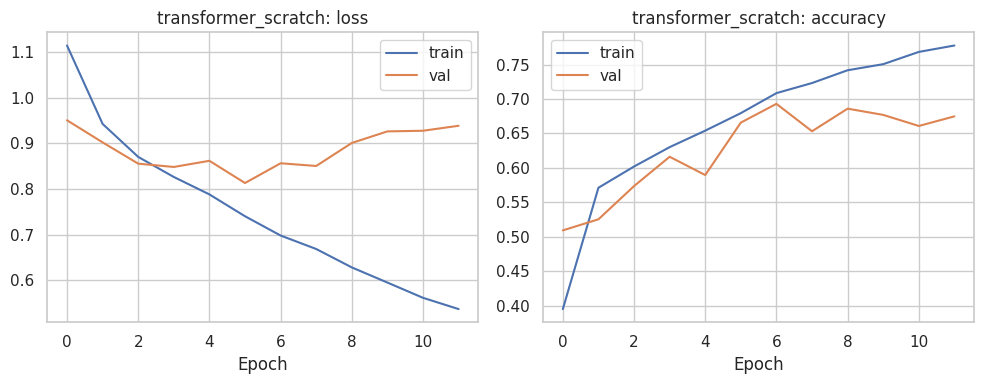

== transformer_scratch | RMSE 0.6029 ==
              precision    recall  f1-score   support

    negative      0.376     0.566     0.451       152
     neutral      0.858     0.732     0.790       693
    positive      0.707     0.737     0.722       589

    accuracy                          0.716      1434
   macro avg      0.647     0.678     0.654      1434
weighted avg      0.745     0.716     0.726      1434



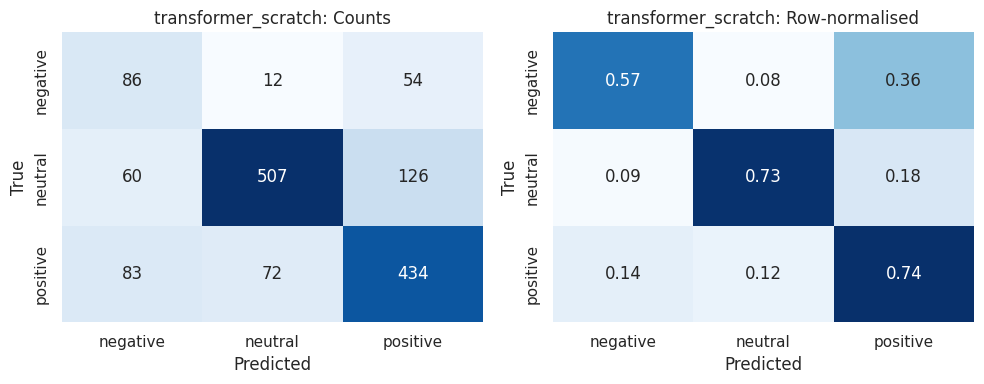

In [9]:
row, model, hist = ex.run("final", seed=42)
print("Final config:", ex.best, "| best epoch", row["best_epoch"])
display(history_table(hist))
plot_history(hist, MODEL)

_, _, test_dl = make_loaders(TOK[ex.best["tok"]][1])
yp, ys, P = predict(model, test_dl)
evaluate(test["label"], yp, MODEL, y_score=ys)
save_predictions(MODEL, test["tweet_id"], test["safe_text"], test["label"], yp, test["agreement"], ys)
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), f"models/{MODEL}.pt")

## Negation and label-noise slices

In [10]:
display(slice_report(["tfidf_logreg", "fasttext", MODEL]).round(3))

model,tfidf_logreg,fasttext,transformer_scratch
slice,,,
agreement < 0.7 (n=583),0.556,0.485,0.541
agreement >= 0.7 (n=851),0.704,0.687,0.719
all (n=1434),0.655,0.605,0.654
no negation (n=1068),0.662,0.619,0.662
with negation (n=366),0.613,0.546,0.614


## Summary
**Summary.** The final Transformer (2 layers, d_model 100, 4 heads, GloVe-initialised word embeddings, no positional encoding, CLS pooling, class-weighted loss) reaches test macro-F1 0.654, RMSE 0.603 and accuracy 0.716. On macro-F1 it ties with TF-IDF + Logistic Regression (0.655) and the BiLSTM (0.650); its RMSE is the worst of the three (0.584 and 0.598 for the other two).

- **What mattered:** only GloVe initialisation (T4, +0.030). Positional encoding, model size, subword tokens, pooling and warm-up were all within seed noise.
- **Word order:** the final model has no positional encoding, so it is a bag-of-words model with attention, and it still matches every other model. On tweets with negation it scores 0.614, the same as Logistic Regression (0.613). Together with T1, this shows that the models trained here get their performance from which words appear, not from their order.
- **Negative class:** with the weighted loss it has the highest negative recall of all models (0.566) but low precision (0.376). Its negative F1 (0.451) is close to Logistic Regression's (0.464).
- **Label noise:** 0.719 on tweets with agreement >= 0.7 and 0.541 below, slightly better than Logistic Regression on the clear tweets and slightly worse on the disputed ones.
- **Overfitting and instability:** validation loss is lowest at epoch 6 (0.813) and rises afterwards while training accuracy keeps increasing. The selected epoch 7 is only mildly overfit (training accuracy 0.709, validation 0.693). Validation metrics jump between neighbouring epochs (RMSE 0.625, 0.692, 0.626 over epochs 7-9), and the seed-42 model scores 0.629 on validation but 0.654 on test, so differences of 0.02-0.03 between models should not be over-interpreted.
- **Role in the study:** it is the no-pretraining reference for Model 5: the same family of architecture as BERTweet, but with only 6.7k tweets to learn from.